# House price prediction

## Objective

The objective of this project is to predict house prices using regression techniques and identify the best-performing model based on evaluation metrics.

## Dataset

- The dataset used in this project is the House Price Prediction dataset obtained from Kaggle.
- It contains information about different houses, including features like area, number of bedrooms, and location, along with their prices.
- This dataset is used to analyze the factors affecting house prices and to build a model for predicting house prices.

## Steps Involved
* Data Collection
* Import Libraries
* Data Cleaning & Preprocessing
* Exploratory Data Analysis (EDA)
* Feature Engineering & Selection
* Model Building
* Model Evaluation
* Testing the Model

## Import required Libraries

In [53]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading dataset and preprocessing

- The dataset contains 20 input features
- It includes 1 target variable (price)
- Each row represents one house
- The target variable (price) represents the selling price of the house

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [4]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [7]:
df.isnull()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [13]:
# Remove unnecessary columns
df = df.drop(['id', 'date'], axis=1)

In [14]:
df.shape

(21613, 19)

In [15]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
21608    False
21609    False
21610    False
21611    False
21612    False
Length: 21613, dtype: bool

In [12]:
print(df.duplicated().sum())

0


### Insights
* The dataset contains no missing values, so no imputation is required
* There are no duplicate records, indicating clean and unique data
* All features have appropriate data types for analysis
* The dataset is already well-structured and ready for modeling
* No major data quality issues were observed

## Feature scaling
Feature scaling was applied to normalize the data so that all features contribute equally to the model.

In [54]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Exploratory Data Analysis

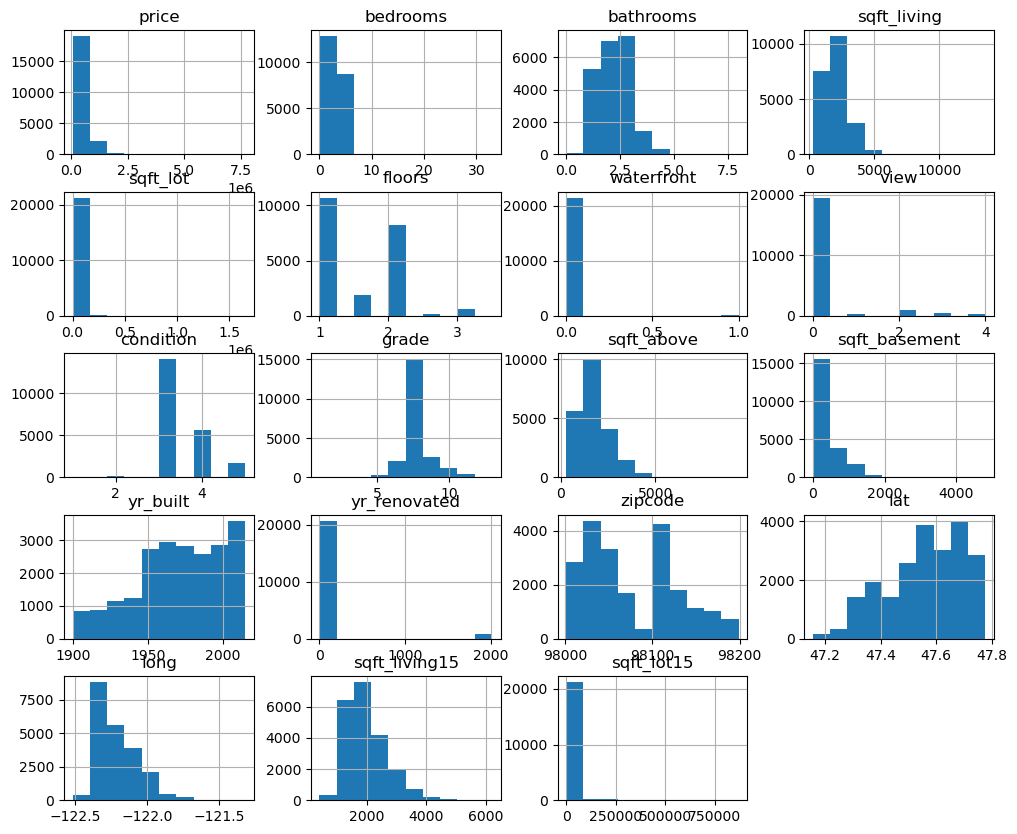

In [19]:
# Histogram
df.hist(figsize=(12,10))
plt.show()

### Insights
* Most houses are concentrated in a mid-price range
* The price distribution is slightly right-skewed (few very high prices)
* Features like area also show uneven distribution

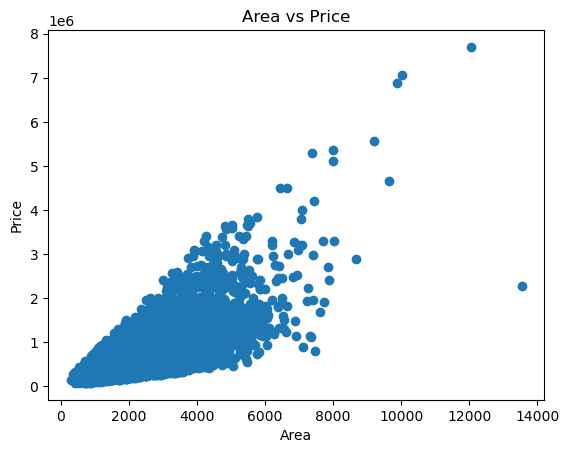

In [20]:
# Scatter plot
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

### Insights
* There is a positive relationship between area and price
* As living area increases, price also increases
* Some points are far from others, indicating possible outliers

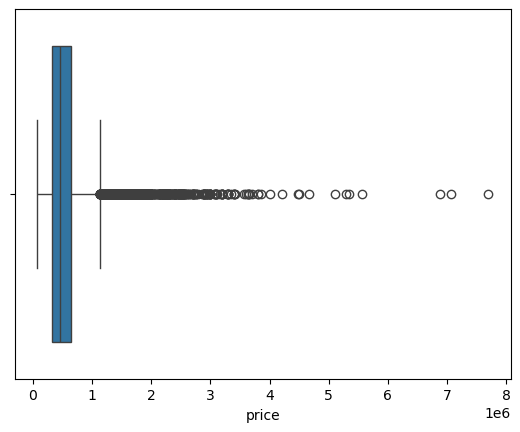

In [21]:
# Boxplot for finding outliers
sns.boxplot(x=df['price'])
plt.show()

### Insights

* The dataset contains outliers in house prices
* Most houses fall within a normal price range
* A few houses have very high prices compared to others

In [ ]:
# Handling Outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

### Correlation Heat map

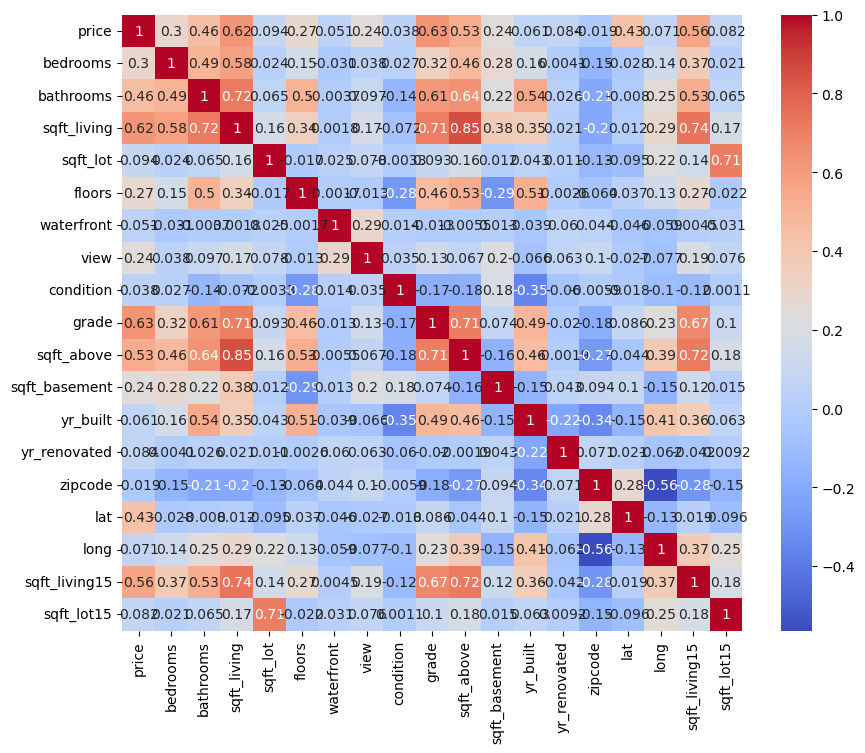

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Insights

* sqft_living has a strong positive correlation with price
* grade and bathrooms also influence price
* Some features have weak or no correlation with price

## Model Building

In [30]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression
Linear Regression is a simple algorithm that assumes a linear relationship between independent variables and the target variable. It tries to fit a straight line that best predicts the output.It is easy to implement and works well when there is a linear relationship between features and price.

In [37]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Decision tree regressor
Decision Tree splits the dataset into smaller subsets based on feature values. It creates a tree-like structure where each branch represents a decision. It can capture non-linear relationships and interactions between variables.

In [32]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Random Forest Regressor
Random Forest is an ensemble method that combines multiple decision trees. Each tree makes a prediction, and the final output is the average of all predictions.It improves accuracy and reduces overfitting compared to a single decision tree.

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Model Evaluation

The performance of the models was evaluated using three metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

* Mean Absolute Error (MAE) measures the average difference between actual and predicted values. A lower MAE indicates better model performance.
* Mean Squared Error (MSE) measures the average of squared differences between actual and predicted values. Lower MSE means the model has fewer large errors.
* R² Score (R-squared) shows how well the model explains the variance in the data. A value closer to 1 indicates a better fit.

These metrics were used to compare the performance of Linear Regression, Decision Tree, and Random Forest models. The model with lower MAE and MSE and higher R² score is considered the best.

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

In [56]:
# Comparison
print("Linear Regression")
lr_results = evaluate(y_test, y_pred_lr)


print("\nDecision Tree")
dt_results = evaluate(y_test, y_pred_dt)


print("\nRandom Forest")
rf_results = evaluate(y_test, y_pred_rf)

Linear Regression
MAE: 86165.02687437035
MSE: 13043334394.762976
R2: 0.6867899638843732

Decision Tree
MAE: 76103.20236932096
MSE: 12314432369.511175
R2: 0.7042931132129325

Random Forest
MAE: 52616.504369117414
MSE: 5921962403.194287
R2: 0.8577957137306398


The models are compared based on their evaluation metrics. The model with the lowest error values (MAE, MSE) and highest R² score is considered the best.

### Insights

* Random Forest is best because it gives more accurate predictions and handles complex relationships better than Linear Regression and Decision Tree.
* Decision Tree performed moderately, while Linear Regression showed the lowest performance.

## Conclusion
* The project successfully built a house price prediction model using regression techniques
* Three models were implemented: Linear Regression, Decision Tree, and Random Forest
* The models were evaluated using MAE, MSE, and R² Score
* Random Forest Regressor performed the best among all models in most cases
* House price is strongly influenced by features like living area, grade, and location-related factors
* The dataset was clean and suitable for building accurate prediction models